# Resolução da Lista de Exercícios — Programação Linear Inteira



**Aluno**: Ettore Gabriel Emilio Reis Braga

**Disciplina**: Programação Linear Inteira

**Professor**: Prof. Franklin Angelo Krukoski

**Data**: Julho de 2026

---

Este notebook integra o relatório da lista de exercícios com o código Python implementado, permitindo a execução interativa e a visualização de todos os resultados.

**Ferramentas e Bibliotecas Utilizadas:**
- **PuLP + CBC**: resolução das relaxações lineares e modelos inteiros
- **NetworkX + Matplotlib**: construção e visualização de grafos e árvores B&B
- **Pandas**: exibição tabular dos dados e dos passos do Branch-and-Bound

## Instalação de dependencias:
 pip install pandas matplotlib networkx

In [44]:
%matplotlib inline
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pulp
from collections import deque

# Compatibilidade NumPy >= 2.0 com NetworkX legado
if not hasattr(np, 'alltrue'):
    np.alltrue = np.all
if not hasattr(np, 'sometrue'):
    np.sometrue = np.any

plt.rcParams.update({'figure.dpi': 110})
EPS = 1e-6

---
## Parte 1: Construção da Árvore Branch-and-Bound

**Estratégia de busca:** busca em profundidade (*depth-first search*, pilha LIFO).

A cada nó resolve-se a **relaxação linear** (variáveis contínuas) com o solver CBC.

**Regra de ramificação:** escolhe-se a variável inteira de *menor índice* com valor fracionário, gerando dois ramos:
- $x_j \leq \lfloor x_j^* \rfloor$: ramo do *piso*, explorado primeiro
- $x_j \geq \lceil x_j^* \rceil$: ramo do *teto*

**Critérios de poda:**
1. **Inviabilidade**: a relaxação do nó não tem solução viável
2. **Integralidade**: a solução da relaxação já é inteira (candidata a incumbente)
3. **Limitante** (*bound*): o valor da relaxação não supera o incumbente corrente

**Legenda das árvores:**
- <span style="color: #1f77b4; font-weight: bold;">Fracionário</span>
- <span style="color: #2ca02c; font-weight: bold;">Inteiro (incumbente)</span>
- <span style="color: #ff7f0e; font-weight: bold;">Podado por limitante</span>
- <span style="color: #d62728; font-weight: bold;">Inviável</span>

In [45]:
# Motor Branch-and-Bound

class Node:
    def __init__(self, nid, parent, branch_txt, bounds):
        self.id         = nid
        self.parent     = parent
        self.branch_txt = branch_txt  # restrição que gerou o nó
        self.bounds     = bounds      # dict var -> (lo, hi)
        self.step       = None        # ordem de exploração
        self.status     = None        # 'inviavel'|'fracionario'|'inteiro'|'podado'
        self.z          = None
        self.sol        = None
        self.note       = ''


def solve_relaxation(prob_data, bounds):
    """Resolve a relaxação linear com limites adicionais em `bounds`."""
    sense       = prob_data['sense']
    names       = prob_data['vars']
    obj         = prob_data['obj']
    constraints = prob_data['constraints']

    m = pulp.LpProblem('relax', sense)
    x = {}
    for n in names:
        lo, hi = bounds.get(n, (0, None))
        x[n] = pulp.LpVariable(n, lowBound=lo, upBound=hi, cat='Continuous')
    m += pulp.lpSum(obj.get(n, 0) * x[n] for n in names)
    for coef, sign, rhs in constraints:
        expr = pulp.lpSum(coef.get(n, 0) * x[n] for n in names)
        if sign == '<=':
            m += expr <= rhs
        elif sign == '>=':
            m += expr >= rhs
        else:
            m += expr == rhs
    status = m.solve(pulp.PULP_CBC_CMD(msg=0))
    if pulp.LpStatus[status] != 'Optimal':
        return None, None
    return pulp.value(m.objective), {n: x[n].value() for n in names}


def first_fractional(sol, int_vars):
    """Retorna (nome, valor) da 1ª variável inteira com valor fracionário."""
    for n in int_vars:
        v = sol[n]
        if abs(v - round(v)) > 1e-4:
            return n, v
    return None, None


def branch_and_bound(prob_data, max_steps=500):
    sense     = prob_data['sense']
    int_vars  = prob_data['int_vars']
    maximize  = (sense == pulp.LpMaximize)
    incumbent_z, incumbent_sol = None, None
    nodes, counter = [], [0]

    def new_node(parent, branch_txt, bounds):
        nd = Node(counter[0], parent, branch_txt, bounds)
        counter[0] += 1
        nodes.append(nd)
        return nd

    root  = new_node(None, 'raiz (LP)', {})
    stack = [root]
    step  = 0

    while stack and step < max_steps:
        nd   = stack.pop()
        step += 1
        nd.step = step
        z, sol = solve_relaxation(prob_data, nd.bounds)

        if z is None:
            nd.status = 'inviavel'
            nd.note   = 'Poda por inviabilidade'
            continue

        nd.z, nd.sol = z, sol

        # poda por limitante
        if incumbent_z is not None:
            worse = (maximize     and z <= incumbent_z + EPS) or \
                    (not maximize and z >= incumbent_z - EPS)
            if worse:
                nd.status = 'podado'
                nd.note   = f'Poda: z={z:.3f} nao melhora incumbente {incumbent_z:.3f}'
                continue

        bn, bv = first_fractional(sol, int_vars)
        if bn is None:
            nd.status = 'inteiro'
            if incumbent_z is None or \
               (maximize and z > incumbent_z) or \
               (not maximize and z < incumbent_z):
                incumbent_z, incumbent_sol = z, dict(sol)
                nd.note = 'Nova solucao incumbente'
            else:
                nd.note = 'Solucao inteira (nao melhora incumbente)'
            continue

        nd.status = 'fracionario'
        f, c = math.floor(bv), math.ceil(bv)

        b_lo = dict(nd.bounds)
        lo, hi = b_lo.get(bn, (0, None))
        b_lo[bn] = (lo, f)
        child_lo = new_node(nd.id, f'{bn} <= {f}', b_lo)

        b_hi = dict(nd.bounds)
        lo, hi = b_hi.get(bn, (0, None))
        b_hi[bn] = (c, hi)
        child_hi = new_node(nd.id, f'{bn} >= {c}', b_hi)

        nd.note = f'Ramifica em {bn} = {bv:.4f}'
        stack.append(child_hi)   # TETO por último → PISO sai primeiro (LIFO)
        stack.append(child_lo)

    return {'nodes': nodes, 'incumbent_z': incumbent_z, 'incumbent_sol': incumbent_sol}


print('Motor B&B carregado.')

Motor B&B carregado.


In [46]:
# Utilitários de visualização da árvore B&B

COLORS = {
    'inteiro':     '#2ca02c',
    'fracionario': '#1f77b4',
    'inviavel':    '#d62728',
    'podado':      '#ff7f0e',
    None:          '#999999',
}


def fmt_sol(sol):
    if sol is None:
        return '--'
    return ', '.join(f'{k}={v:.3f}'.rstrip('0').rstrip('.') for k, v in sol.items())


def tree_layout(nodes):
    children = {n.id: [] for n in nodes}
    root_id  = None
    for n in nodes:
        if n.parent is None:
            root_id = n.id
        else:
            children[n.parent].append(n.id)

    depth = {}
    def setdepth(nid, d):
        depth[nid] = d
        for c in children[nid]:
            setdepth(c, d + 1)
    setdepth(root_id, 0)

    xpos, counter = {}, [0]
    def assign(nid):
        ch = children[nid]
        if not ch:
            xpos[nid] = counter[0]; counter[0] += 1
        else:
            for c in ch: assign(c)
            xpos[nid] = sum(xpos[c] for c in ch) / len(ch)
    assign(root_id)
    return {n.id: (xpos[n.id], -depth[n.id]) for n in nodes}


def draw_tree(res, title='Árvore B&B'):
    nodes = res['nodes']
    pos   = tree_layout(nodes)
    G     = nx.DiGraph()
    for n in nodes:
        G.add_node(n.id)
        if n.parent is not None:
            G.add_edge(n.parent, n.id)

    fig, ax = plt.subplots(figsize=(max(8, len(nodes) * 1.05), 6))
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#888', arrows=False)

    for n in nodes:
        x, y = pos[n.id]
        col  = COLORS.get(n.status, '#999999')
        ax.scatter([x], [y], s=1500, c=col, zorder=3, edgecolors='black')
        lbl = f'N{n.id}'
        if n.step:
            lbl += f'\n(p{n.step})'
        ax.text(x, y, lbl, ha='center', va='center',
                color='white', fontsize=8, fontweight='bold', zorder=4)

        if n.status == 'inviavel':
            info = 'inviável'
        elif n.z is not None:
            info = f'z={n.z:.2f}\n{fmt_sol(n.sol)}'
        else:
            info = '(não explorado)'
        ax.text(x, y - 0.32, info, ha='center', va='top', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.2', fc='#f5f5f5', ec='#ccc'))

        if n.parent is not None:
            px, py = pos[n.parent]
            lx = px + 0.70 * (x - px)
            ly = py + 0.70 * (y - py) + 0.13
            ax.text(lx, ly, n.branch_txt, fontsize=7.5, color='#1a1a1a',
                    ha='center', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', fc='#fff7e0', ec='#e0c060'))

    patches = [
        mpatches.Patch(color='#1f77b4', label='Fracionário'),
        mpatches.Patch(color='#2ca02c', label='Inteiro (incumbente)'),
        mpatches.Patch(color='#ff7f0e', label='Podado por limitante'),
        mpatches.Patch(color='#d62728', label='Inviável'),
    ]
    ax.legend(handles=patches, loc='upper right', fontsize=8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


def results_table(res):
    rows = []
    for n in sorted([x for x in res['nodes'] if x.step], key=lambda a: a.step):
        rows.append({
            'Passo':      n.step,
            'Nó':         f'N{n.id}',
            'Ramo':       n.branch_txt,
            'z_LP':       f'{n.z:.3f}' if n.z is not None else '--',
            'Solução LP': fmt_sol(n.sol),
            'Status':     n.status,
            'Observação': n.note,
        })
    return pd.DataFrame(rows)


print('Utilitários de visualização carregados.')

Utilitários de visualização carregados.


### Exercício 1

$$\max\; z = x_1 + 5x_2 + 9x_3 + 5x_4$$

Sujeito a:
- $x_1 + 3x_2 + 9x_3 + 6x_4 \leq 16$
- $6x_1 + 6x_2 + 7x_4 \leq 19$
- $7x_1 + 8x_2 + 18x_3 + 3x_4 \leq 44$
- $x_1, x_2, x_3, x_4 \geq 0$ e inteiras

A relaxação na raiz fornece $z = 22{,}33$ (fracionária). A busca em profundidade explora **13 nós**.

In [47]:
prob_ex1 = {
    'name':     'Exercício 1',
    'sense':    pulp.LpMaximize,
    'vars':     ['x1', 'x2', 'x3', 'x4'],
    'int_vars': ['x1', 'x2', 'x3', 'x4'],
    'obj':      {'x1': 1, 'x2': 5, 'x3': 9, 'x4': 5},
    'constraints': [
        ({'x1': 1, 'x2': 3, 'x3': 9, 'x4': 6}, '<=', 16),
        ({'x1': 6, 'x2': 6,           'x4': 7}, '<=', 19),
        ({'x1': 7, 'x2': 8, 'x3': 18, 'x4': 3}, '<=', 44),
    ],
}

res1 = branch_and_bound(prob_ex1)
print(f"z* = {res1['incumbent_z']}  |  {res1['incumbent_sol']}")
print(f"Nós explorados: {len([n for n in res1['nodes'] if n.step])}")
results_table(res1)

z* = 20.0  |  {'x1': 1.0, 'x2': 2.0, 'x3': 1.0, 'x4': 0.0}
Nós explorados: 13


,Passo,Nó,Ramo,z_LP,Solução LP,Status,Observação
0,1,N0,raiz (LP),22.333,"x1=0, x2=3.167, x3=0.722, x4=0",fracionario,Ramifica em x2 = 3.1667
1,2,N1,x2 <= 3,22.000,"x1=0, x2=3, x3=0.778, x4=0",fracionario,Ramifica em x3 = 0.7778
2,3,N3,x3 <= 0,15.714,"x1=0, x2=3, x3=0, x4=0.143",fracionario,Ramifica em x4 = 0.1429
3,4,N5,x4 <= 0,15.167,"x1=0.167, x2=3, x3=0, x4=0",fracionario,Ramifica em x1 = 0.1667
4,5,N7,x1 <= 0,15.000,"x1=0, x2=3, x3=0, x4=0",inteiro,Nova solucao incumbente
5,6,N8,x1 >= 1,11.833,"x1=1, x2=2.167, x3=0, x4=0",podado,Poda: z=11.833 nao melhora incumbente 15.000
6,7,N6,x4 >= 1,15.000,"x1=0, x2=2, x3=0, x4=1",podado,Poda: z=15.000 nao melhora incumbente 15.000
7,8,N4,x3 >= 1,20.667,"x1=0, x2=2.333, x3=1, x4=0",fracionario,Ramifica em x2 = 2.3333
8,9,N9,x2 <= 2,20.000,"x1=0, x2=2, x3=1.111, x4=0",fracionario,Ramifica em x3 = 1.1111
9,10,N11,x3 <= 1,20.000,"x1=1, x2=2, x3=1, x4=0",inteiro,Nova solucao incumbente


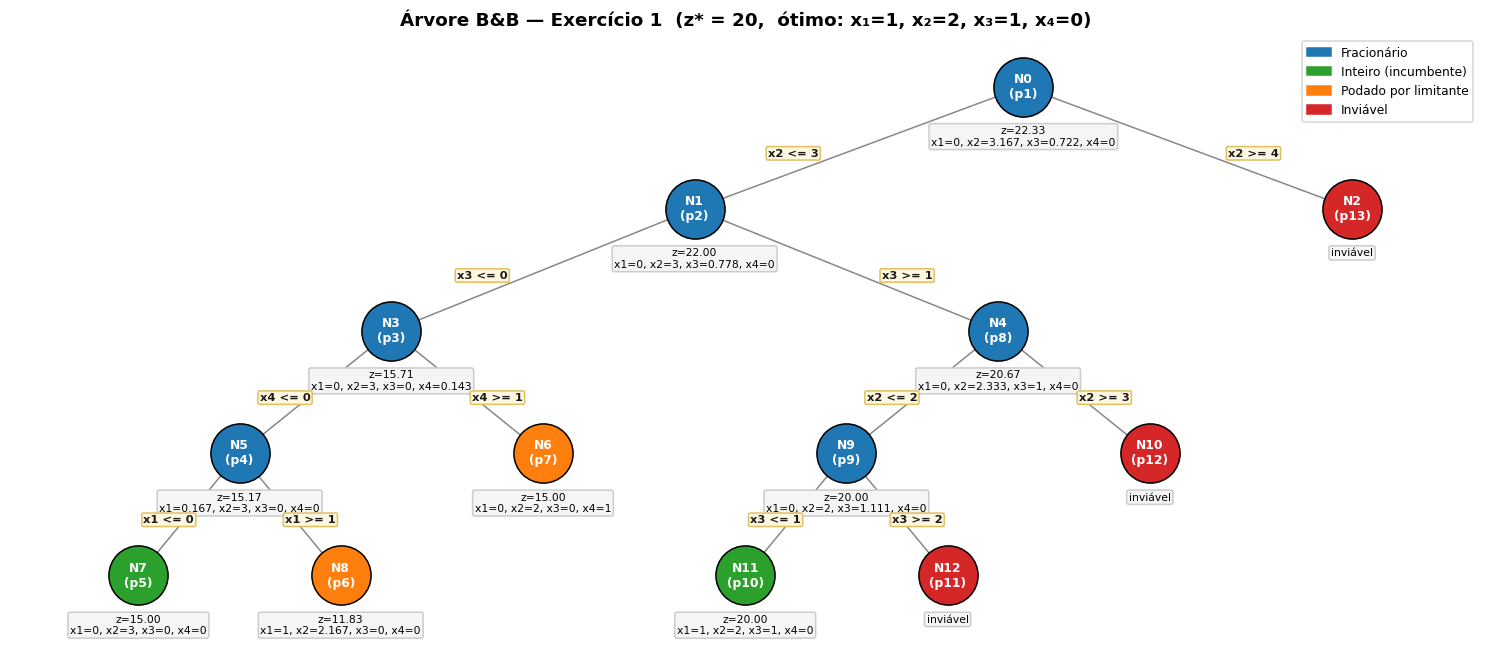

In [48]:
draw_tree(res1, 'Árvore B&B — Exercício 1  (z* = 20,  ótimo: x₁=1, x₂=2, x₃=1, x₄=0)')

### Exercício 2

$$\max\; z = 7x_1 + 9x_2 + x_3 + 6x_4$$

Sujeito a:
- $8x_1 + 2x_2 + 4x_3 + 2x_4 \leq 16$
- $4x_1 + 8x_2 + 2x_3 \leq 20$
- $7x_1 + 6x_3 + 2x_4 \leq 11$
- $x_1, x_2, x_4 \geq 0$ **inteiras**;  $x_3 \geq 0$ **contínua**

Como $x_3$ é contínua, a ramificação incide apenas sobre $x_1, x_2, x_4$. A árvore completa tem **7 nós**.

In [49]:
prob_ex2 = {
    'name':     'Exercício 2',
    'sense':    pulp.LpMaximize,
    'vars':     ['x1', 'x2', 'x3', 'x4'],
    'int_vars': ['x1', 'x2', 'x4'],      # x3 é contínua
    'obj':      {'x1': 7, 'x2': 9, 'x3': 1, 'x4': 6},
    'constraints': [
        ({'x1': 8, 'x2': 2, 'x3': 4, 'x4': 2}, '<=', 16),
        ({'x1': 4, 'x2': 8, 'x3': 2},           '<=', 20),
        ({'x1': 7,           'x3': 6, 'x4': 2}, '<=', 11),
    ],
}

res2 = branch_and_bound(prob_ex2)
print(f"z* = {res2['incumbent_z']:.4f}  |  {res2['incumbent_sol']}")
results_table(res2)

z* = 48.1667  |  {'x1': 0.0, 'x2': 2.0, 'x3': 0.16666667, 'x4': 5.0}


,Passo,Nó,Ramo,z_LP,Solução LP,Status,Observação
0,1,N0,raiz (LP),55.500,"x1=0, x2=2.5, x3=0, x4=5.5",fracionario,Ramifica em x2 = 2.5000
1,2,N1,x2 <= 2,51.000,"x1=0, x2=2, x3=0, x4=5.5",fracionario,Ramifica em x4 = 5.5000
2,3,N3,x4 <= 5,49.000,"x1=0.143, x2=2, x3=0, x4=5",fracionario,Ramifica em x1 = 0.1429
3,4,N5,x1 <= 0,48.167,"x1=0, x2=2, x3=0.167, x4=5",inteiro,Nova solucao incumbente
4,5,N6,x1 >= 1,37.000,"x1=1, x2=2, x3=0, x4=2",podado,Poda: z=37.000 nao melhora incumbente 48.167
5,6,N4,x4 >= 6,--,--,inviavel,Poda por inviabilidade
6,7,N2,x2 >= 3,--,--,inviavel,Poda por inviabilidade


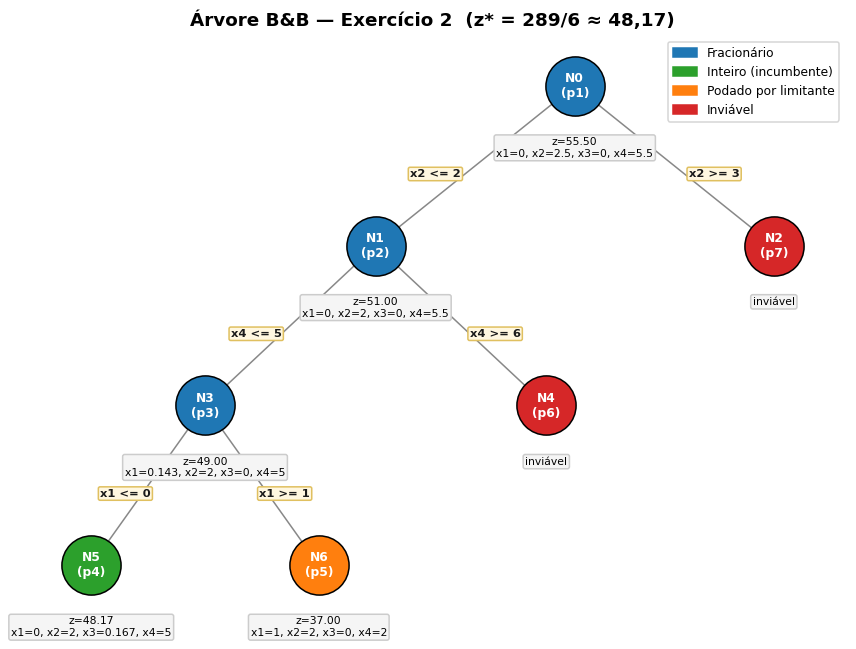

In [50]:
draw_tree(res2, 'Árvore B&B — Exercício 2  (z* = 289/6 ≈ 48,17)')

### Exercício 3

$$\min\; z = 3x_1 + 4x_2 + 3x_3$$

Sujeito a:
- $3x_1 + 2x_2 + 2x_3 \geq 13$
- $2x_1 + 5x_2 + 3x_3 \geq 15$
- $2x_1 + x_2 + 2x_3 \geq 9$
- $x_2, x_3 \geq 0$ **inteiras**;  $x_1 \geq 0$ **contínua**

$x_1$ é contínua; ramifica-se sobre $x_2, x_3$. A árvore completa tem **9 nós**.

In [51]:
prob_ex3 = {
    'name':     'Exercício 3',
    'sense':    pulp.LpMinimize,
    'vars':     ['x1', 'x2', 'x3'],
    'int_vars': ['x2', 'x3'],   # x1 é contínua
    'obj':      {'x1': 3, 'x2': 4, 'x3': 3},
    'constraints': [
        ({'x1': 3, 'x2': 2, 'x3': 2}, '>=', 13),
        ({'x1': 2, 'x2': 5, 'x3': 3}, '>=', 15),
        ({'x1': 2, 'x2': 1, 'x3': 2}, '>=',  9),
    ],
}

res3 = branch_and_bound(prob_ex3)
print(f"z* = {res3['incumbent_z']}  |  {res3['incumbent_sol']}")
results_table(res3)

z* = 17.0000001  |  {'x1': 1.6666667, 'x2': 0.0, 'x3': 4.0}


,Passo,Nó,Ramo,z_LP,Solução LP,Status,Observação
0,1,N0,raiz (LP),16.556,"x1=2.778, x2=1.222, x3=1.111",fracionario,Ramifica em x2 = 1.2222
1,2,N1,x2 <= 1,16.600,"x1=2.6, x2=1, x3=1.6",fracionario,Ramifica em x3 = 1.6000
2,3,N3,x3 <= 1,17.500,"x1=3.5, x2=1, x3=1",inteiro,Nova solucao incumbente
3,4,N4,x3 >= 2,16.636,"x1=2.455, x2=0.818, x3=2",fracionario,Ramifica em x2 = 0.8182
4,5,N5,x2 <= 0,16.800,"x1=1.8, x2=0, x3=3.8",fracionario,Ramifica em x3 = 3.8000
5,6,N7,x3 <= 3,18.000,"x1=3, x2=0, x3=3",podado,Poda: z=18.000 nao melhora incumbente 17.500
6,7,N8,x3 >= 4,17.000,"x1=1.667, x2=0, x3=4",inteiro,Nova solucao incumbente
7,8,N6,x2 >= 1,17.000,"x1=2.333, x2=1, x3=2",podado,Poda: z=17.000 nao melhora incumbente 17.000
8,9,N2,x2 >= 2,18.500,"x1=3.5, x2=2, x3=0",podado,Poda: z=18.500 nao melhora incumbente 17.000


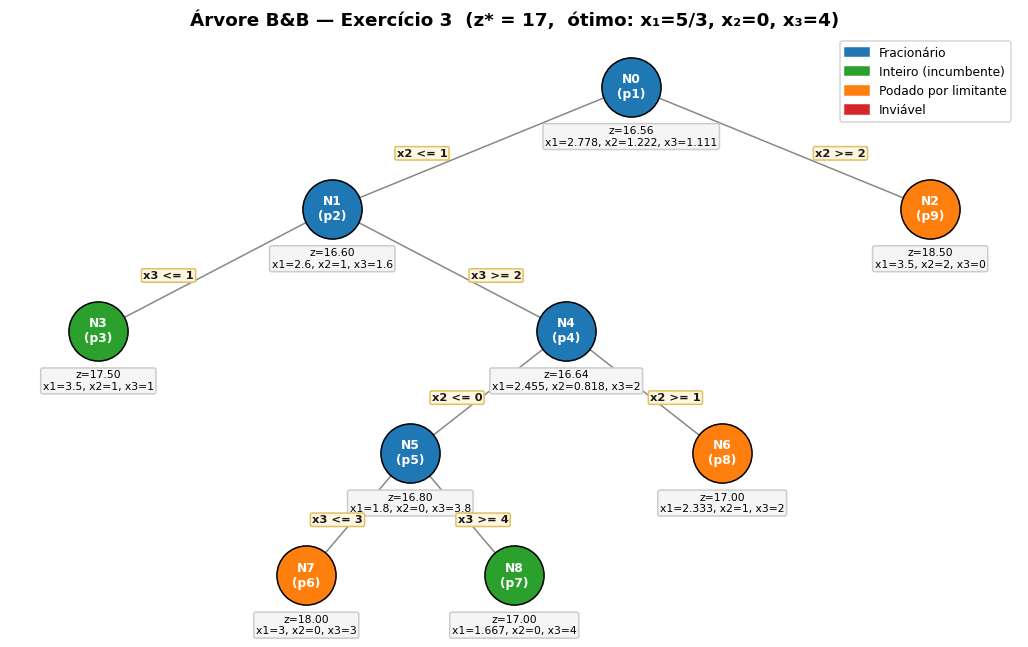

In [52]:
draw_tree(res3, 'Árvore B&B — Exercício 3  (z* = 17,  ótimo: x₁=5/3, x₂=0, x₃=4)')

### Exercício 4

$$\min\; z = 2x_1 + 3x_2 + 5x_3$$

Sujeito a:
- $x_1 + 2x_2 + 3x_3 \geq 7$
- $3x_1 + 2x_2 + 3x_3 \geq 11$
- $x_1, x_3 \geq 0$ **inteiras**;  $x_2 \geq 0$ **contínua**

A relaxação na raiz já fornece $x_1 = 2$, $x_3 = 0$ (inteiros) com $x_2 = 2{,}5$ (contínua). A árvore se encerra na raiz **sem ramificação**.

In [53]:
prob_ex4 = {
    'name':     'Exercício 4',
    'sense':    pulp.LpMinimize,
    'vars':     ['x1', 'x2', 'x3'],
    'int_vars': ['x1', 'x3'],   # x2 é contínua
    'obj':      {'x1': 2, 'x2': 3, 'x3': 5},
    'constraints': [
        ({'x1': 1, 'x2': 2, 'x3': 3}, '>=',  7),
        ({'x1': 3, 'x2': 2, 'x3': 3}, '>=', 11),
    ],
}

res4 = branch_and_bound(prob_ex4)
print(f"z* = {res4['incumbent_z']}  |  {res4['incumbent_sol']}")
print('A árvore se encerra na raiz (sem ramificação): relaxação LP já é inteira nas variáveis exigidas.')
results_table(res4)

z* = 11.5  |  {'x1': 2.0, 'x2': 2.5, 'x3': 0.0}
A árvore se encerra na raiz (sem ramificação): relaxação LP já é inteira nas variáveis exigidas.


,Passo,Nó,Ramo,z_LP,Solução LP,Status,Observação
0,1,N0,raiz (LP),11.500,"x1=2, x2=2.5, x3=0",inteiro,Nova solucao incumbente


---
## Parte 2: Formulação de Problemas de PLI

Apresentam-se apenas os modelos matemáticos (variáveis de decisão, função objetivo e restrições), conforme solicitado. Não há código de execução nesta parte.

### Exercício 1: Carregamento do avião cargueiro

**Variáveis:** $n_{ik} \in \mathbb{Z}_{\geq 0}$ = contêineres do tipo $i \in \{1,2,3\}$ no compartimento $k \in \{F,C,T\}$;  $g_j \geq 0$ = carga a granel $j \in \{4,5\}$ (ton) no porão $G$.

**Objetivo** (maximizar lucro):
$$\max\; z = \sum_{k}\bigl(200\,w_1 n_{1k} + 220\,w_2 n_{2k} + 175\,w_3 n_{3k}\bigr) + 235\,g_4 + 180\,g_5$$

**Restrições de peso** (ton: $F=5, C=7, T=6, G=7$):
$$\textstyle\sum_i w_i n_{iF} \leq 5, \quad \sum_i w_i n_{iC} \leq 7, \quad \sum_i w_i n_{iT} \leq 6, \quad g_4+g_5 \leq 7$$

**Equilíbrio de voo:**
$$\frac{\sum_i w_i n_{iF}}{5} = \frac{\sum_i w_i n_{iC}}{7} = \frac{\sum_i w_i n_{iT}}{6} = \frac{g_4+g_5}{7}$$

### Exercício 2: Combate ao incêndio florestal

**Variáveis:** $x_1, x_2, x_3 \in \mathbb{Z}_{\geq 0}$ = helicópteros AH-1, aviões-tanque e aviões B67.

$$\min\; z = 6000x_1 + 12000x_2 + 30000x_3$$

- $3(15000x_1 + 40000x_2 + 85000x_3) \geq 3\,000\,000$ -> área coberta
- $2x_1 \leq 10$ -> pilotos de helicóptero
- $2x_2 + 2x_3 \leq 14$ -> pilotos de avião
- $x_2 + 3x_3 \leq 22$ -> operadores

### Exercício 4: Redução de peso do automóvel

**Variáveis:** $x_j \in \{0,1\}$, $j = 1,\ldots,12$ (1 se a alteração $j$ for implementada).

$$\min\; z = \sum_{j=1}^{12} c_j x_j \qquad \text{s.a.} \qquad \sum_{j=1}^{12} r_j x_j \geq 180$$

Reduções $r = (30,20,25,40,15,10,60,80,40,30,50,35)$ kg  
Custos $c = (130,110,120,150,80,80,360,400,160,120,200,160)$ (mil \$)

### Exercício 5: Localização de Centros de Distribuição

**Variáveis:** $y_i \in \{0,1\}$ = 1 se o CD $i$ é instalado;  $x_{ij} \geq 0$ = quantidade enviada de $i$ a $j$.

$$\min\; z = \sum_i f_i y_i + \sum_i\sum_j (v_i + c_{ij})\,x_{ij}$$

- $\sum_i x_{ij} = d_j$ para todo $j$ -> atender demanda
- $\sum_j x_{ij} \leq \text{Cap}_i\, y_i$ para todo $i$ -> capacidade e abertura (só despacha de CD aberto)

---
## Parte 3: Transporte, Transbordo e Designação

Os problemas de transporte são modelados como:
$$\min \sum_{ij} c_{ij} x_{ij} \quad \text{s.a.} \quad \sum_j x_{ij} \leq s_i \;(\text{oferta}), \quad \sum_i x_{ij} = d_j \;(\text{demanda}), \quad x_{ij} \geq 0$$

Em todos os casos a oferta total é maior ou igual à demanda total. O excesso é absorvido pela folga da oferta.

O problema de designação (Ex. 5) usa $x_{ij} \in \{0,1\}$ com $\sum_j x_{ij} = 1$ e $\sum_i x_{ij} = 1$.

In [54]:
# Funções de resolução: transporte e designação

def solve_transport(cost, supply, demand):
    """min sum c_ij x_ij  s.a.  sum_j x_ij <= s_i,  sum_i x_ij = d_j."""
    m_rows, n_cols = len(supply), len(demand)
    prob = pulp.LpProblem('transp', pulp.LpMinimize)
    x = [[pulp.LpVariable(f'x_{i}_{j}', lowBound=0)
          for j in range(n_cols)] for i in range(m_rows)]
    prob += pulp.lpSum(cost[i][j] * x[i][j]
                       for i in range(m_rows) for j in range(n_cols))
    for i in range(m_rows):
        prob += pulp.lpSum(x[i][j] for j in range(n_cols)) <= supply[i]
    for j in range(n_cols):
        prob += pulp.lpSum(x[i][j] for i in range(m_rows)) == demand[j]
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    X = np.array([[x[i][j].value() for j in range(n_cols)] for i in range(m_rows)])
    return X, pulp.value(prob.objective)


def solve_assignment(cost):
    """Problema de designação com variáveis binárias."""
    n = len(cost)
    prob = pulp.LpProblem('assign', pulp.LpMinimize)
    x = [[pulp.LpVariable(f'x_{i}_{j}', cat='Binary')
          for j in range(n)] for i in range(n)]
    prob += pulp.lpSum(cost[i][j] * x[i][j] for i in range(n) for j in range(n))
    for i in range(n):
        prob += pulp.lpSum(x[i][j] for j in range(n)) == 1
    for j in range(n):
        prob += pulp.lpSum(x[i][j] for i in range(n)) == 1
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    X = np.array([[int(round(x[i][j].value())) for j in range(n)] for i in range(n)])
    return X, pulp.value(prob.objective)


def show_transport_matrix(X, rows, cols, title, fmt='{:.0f}'):
    """Exibe a matriz de transporte destacando em verde as rotas utilizadas."""
    fig, ax = plt.subplots(figsize=(1.5 + 0.9 * len(cols), 1.0 + 0.55 * len(rows)))
    ax.axis('off')
    cell = [[fmt.format(X[i][j]) if X[i][j] > 1e-6 else '·'
             for j in range(len(cols))] for i in range(len(rows))]
    tbl = ax.table(cellText=cell, rowLabels=rows, colLabels=cols,
                   cellLoc='center', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.5)
    for i in range(len(rows)):
        for j in range(len(cols)):
            if X[i][j] > 1e-6:
                tbl[(i + 1, j)].set_facecolor('#cfe8cf')
    ax.set_title(title, fontweight='bold', pad=6)
    plt.tight_layout()
    plt.show()


print('Funções de transporte e designação carregadas.')

Funções de transporte e designação carregadas.


### Exercício 1: Transporte (3 fábricas × 4 mercados)

Oferta $(220, 180, 230)$, demanda $(150, 165, 210, 90)$; oferta total $630 > 615$.

| | M1 | M2 | M3 | M4 |
|---|---|---|---|---|
| **F1** | 10 | 7 | 5 | 6 |
| **F2** | 12 | 7 | 6 | 4 |
| **F3** | 13 | 6 | 3 | 5 |

Custo mínimo: R$ 3,625.00


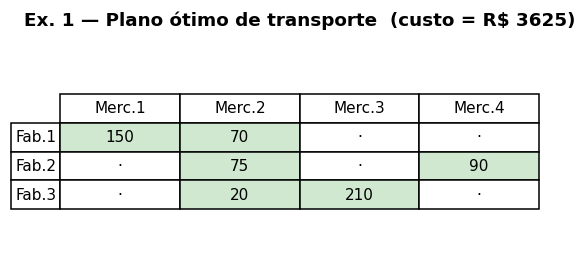

In [55]:
cost1 = [[10, 7, 5, 6],
         [12, 7, 6, 4],
         [13, 6, 3, 5]]
sup1  = [220, 180, 230]
dem1  = [150, 165, 210, 90]

X1, z1 = solve_transport(cost1, sup1, dem1)
print(f'Custo mínimo: R$ {z1:,.2f}')
show_transport_matrix(X1,
    rows=['Fab.1', 'Fab.2', 'Fab.3'],
    cols=['Merc.1', 'Merc.2', 'Merc.3', 'Merc.4'],
    title=f'Ex. 1 — Plano ótimo de transporte  (custo = R$ {z1:.0f})')

### Exercício 2: Compra de pneus (Expresso Rápido Faxina)

Modelado como transporte: ofertas = pneus por revendedor $(A=12000, B=6000, C=4000)$; demandas = pneus por terminal $(4000, 8000, 3000, 5000)$.

Custo mínimo: R$ 1,272,000.00


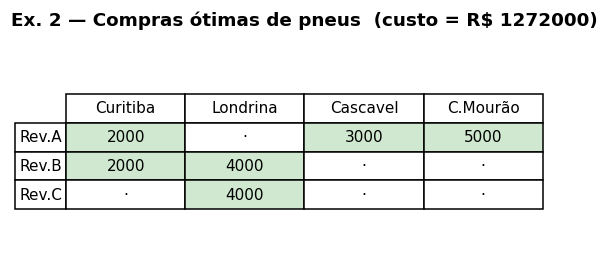

In [56]:
# Custo[revendedor][terminal]
cost2 = [[70, 74, 62, 62],
         [64, 62, 68, 72],
         [68, 65, 64, 66]]
sup2  = [12000, 6000, 4000]
dem2  = [4000, 8000, 3000, 5000]

X2, z2 = solve_transport(cost2, sup2, dem2)
print(f'Custo mínimo: R$ {z2:,.2f}')
show_transport_matrix(X2,
    rows=['Rev.A', 'Rev.B', 'Rev.C'],
    cols=['Curitiba', 'Londrina', 'Cascavel', 'C.Mourão'],
    title=f'Ex. 2 — Compras ótimas de pneus  (custo = R$ {z2:.0f})')

### Exercício 3: Aquisição de combustível

Ofertas (mil galões) $(320, 270, 150)$; demandas $(100, 180, 300)$.

Custo mínimo: US$ 51,990,000


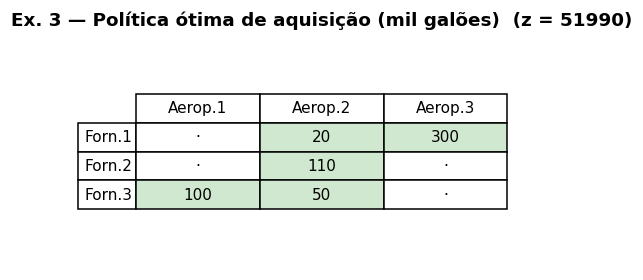

In [57]:
cost3 = [[92, 89, 90],
         [91, 91, 95],
         [87, 90, 92]]
sup3  = [320, 270, 150]
dem3  = [100, 180, 300]

X3, z3 = solve_transport(cost3, sup3, dem3)
print(f'Custo mínimo: US$ {z3 * 1000:,.0f}')
show_transport_matrix(X3,
    rows=['Forn.1', 'Forn.2', 'Forn.3'],
    cols=['Aerop.1', 'Aerop.2', 'Aerop.3'],
    title=f'Ex. 3 — Política ótima de aquisição (mil galões)  (z = {z3:.0f})')

### Exercício 4: Mercados "Deise-Luzia"

Três centros $C_1, C_2, C_3$ (capacidades $500, 750, 400$) atendem 11 armazéns. Custo $c_{ij} = 0{,}50 \cdot d_{ij}$ (\$/ton).

Custo mínimo: $ 16,678.50


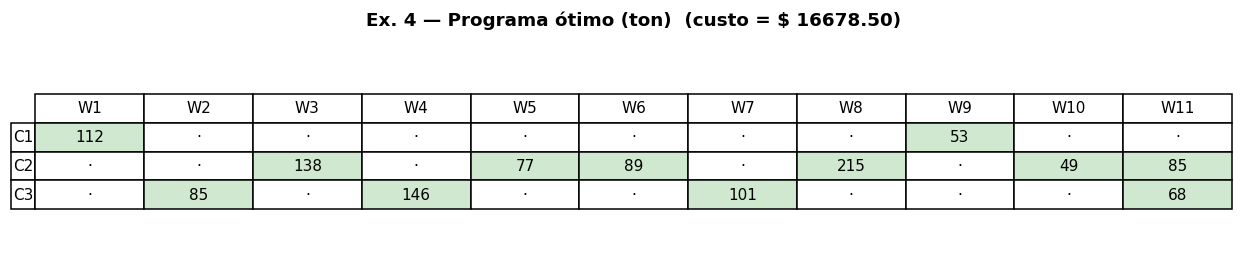

In [58]:
dist4 = [
    [10, 22, 29, 45, 11, 31, 42, 61, 36, 21, 45],
    [25, 35, 17, 38,  9, 17, 65, 45, 42,  5, 41],
    [18, 19, 22, 29, 24, 54, 39, 78, 51, 14, 38],
]
cost4 = [[0.5 * d for d in row] for row in dist4]
cap4  = [500, 750, 400]
dem4  = [112, 85, 138, 146, 77, 89, 101, 215, 53, 49, 153]

X4, z4 = solve_transport(cost4, cap4, dem4)
print(f'Custo mínimo: $ {z4:,.2f}')
show_transport_matrix(X4,
    rows=['C1', 'C2', 'C3'],
    cols=[f'W{j+1}' for j in range(11)],
    title=f'Ex. 4 — Programa ótimo (ton)  (custo = $ {z4:.2f})')

---
## Parte 4: Mínima Arborescência e Fluxo Máximo

Os pesos/capacidades foram transcritos das figuras do enunciado. Os algoritmos foram implementados em Python.

**Mínima Árvore Geradora:** dado um grafo não-dirigido $G=(V,E,w)$, encontrar $T \subseteq E$ que conecta todos os vértices com $\sum_{e \in T} w_e$ mínimo.

**Fluxo Máximo (Edmonds-Karp):** algoritmo de Ford-Fulkerson usando BFS no grafo residual para encontrar caminhos aumentantes (complexidade $O(VE^2)$).

In [59]:
# Algoritmos: Kruskal e Prim

def kruskal(nodes, edges):
    """Kruskal com Union-Find. Retorna (arvore, custo_total, log)."""
    parent = {v: v for v in nodes}

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    log, tree, total = [], [], 0
    for u, v, w in sorted(edges, key=lambda e: e[2]):
        ru, rv = find(u), find(v)
        if ru != rv:
            parent[ru] = rv
            tree.append((u, v, w))
            total += w
            log.append((u, v, w, 'ACEITA', f'une {{{u}}} e {{{v}}}'))
        else:
            log.append((u, v, w, 'rejeita', 'formaria ciclo'))
    return tree, total, log


def prim(nodes, edges, start):
    """Prim guloso a partir de `start`. Retorna (arvore, custo_total, log)."""
    adj = {v: [] for v in nodes}
    for u, v, w in edges:
        adj[u].append((w, v))
        adj[v].append((w, u))

    visited = {start}
    log, tree, total = [], [], 0
    while len(visited) < len(nodes):
        best = None
        for u in visited:
            for w, v in adj[u]:
                if v not in visited and (best is None or w < best[2]):
                    best = (u, v, w)
        if best is None:
            break
        u, v, w = best
        visited.add(v)
        tree.append((u, v, w))
        total += w
        log.append((u, v, w, 'ACEITA', f'adiciona nó {v} via ({u},{v})'))
    return tree, total, log


def mst_log_df(log_k, log_p):
    def to_df(log):
        return pd.DataFrame(
            [{'Iter.': i, 'Aresta': f'({u},{v})', 'Peso': w, 'Decisão': dec, 'Obs.': obs}
             for i, (u, v, w, dec, obs) in enumerate(log, 1)])
    print('--- Kruskal ---')
    display(to_df(log_k))
    print('--- Prim ---')
    display(to_df(log_p))


print('Algoritmos Kruskal e Prim carregados.')

Algoritmos Kruskal e Prim carregados.


In [60]:
# Algoritmo Edmonds-Karp (BFS no grafo residual)

def edmonds_karp(nodes, arcs, source, sink):
    """Fluxo máximo pelo método de Edmonds-Karp.
    Retorna (fluxo_maximo, dict_fluxo_positivo, lista_de_passos).
    """
    cap = {}
    adj = {v: set() for v in nodes}
    for u, v, c in arcs:
        cap[(u, v)] = cap.get((u, v), 0) + c
        cap.setdefault((v, u), 0)
        adj[u].add(v)
        adj[v].add(u)

    flow    = {k: 0 for k in cap}
    steps   = []
    maxflow = 0

    while True:
        # BFS no grafo residual
        prev = {source: None}
        q    = deque([source])
        while q:
            u = q.popleft()
            if u == sink:
                break
            for v in adj[u]:
                if v not in prev and cap[(u, v)] - flow[(u, v)] > 1e-9:
                    prev[v] = u
                    q.append(v)
        if sink not in prev:
            break  # sem caminho aumentante → parar

        # reconstrói caminho e calcula gargalo
        path, v = [], sink
        while prev[v] is not None:
            path.append((prev[v], v))
            v = prev[v]
        path.reverse()
        bottleneck = min(cap[e] - flow[e] for e in path)
        for u, v in path:
            flow[(u, v)] += bottleneck
            flow[(v, u)] -= bottleneck
        maxflow += bottleneck
        caminho = [source] + [v for _, v in path]
        steps.append({
            'Caminho':     ' -> '.join(str(x) for x in caminho),
            'Gargalo':     int(bottleneck),
            'Fluxo acum.': int(maxflow),
        })

    pos_flow = {k: f for k, f in flow.items() if f > 0}
    return maxflow, pos_flow, steps


print('Algoritmo Edmonds-Karp carregado.')

Algoritmo Edmonds-Karp carregado.


In [61]:
# Visualização de grafos (MST e fluxo)

def draw_graph(nodes, edges, pos, title, tree=None, directed=False, flow=None):
    G = nx.DiGraph() if directed else nx.Graph()
    for e in edges:
        G.add_edge(e[0], e[1], w=e[2])

    tree_set = set()
    if tree:
        tree_set = {frozenset((u, v)) for u, v, _ in tree}

    ecolors, widths = [], []
    for u, v in G.edges():
        if frozenset((u, v)) in tree_set:
            ecolors.append('#d62728'); widths.append(3.2)
        else:
            ecolors.append('#bbbbbb'); widths.append(1.3)

    fig, ax = plt.subplots(figsize=(10, 7))
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=ecolors, width=widths,
                           arrows=directed, arrowsize=18)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#2ec4c4',
                           node_size=650, edgecolors='black')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight='bold')

    if flow is not None:
        edge_lbls = {}
        for u, v, d in G.edges(data=True):
            f_val = int(flow.get((u, v), 0))
            edge_lbls[(u, v)] = f'{f_val}/{d["w"]}'
    else:
        edge_lbls = {(u, v): d['w'] for u, v, d in G.edges(data=True)}

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_lbls, ax=ax,
                                 font_size=7, label_pos=0.5,
                                 bbox=dict(boxstyle='round,pad=0.1',
                                           fc='white', ec='none'))
    ax.set_title(title, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


print('Função draw_graph carregada.')

Função draw_graph carregada.


### Exercício 1: Mínima Árvore Geradora (12 nós)

Grafo não-dirigido com 12 nós e 19 arestas. Custo total esperado $= 74$.

In [62]:
EX1_EDGES = [
    (11,7,6),(11,12,11),(12,10,13),(7,6,22),(7,10,9),
    (6,3,5),(6,5,7),(3,1,7),(3,5,8),(3,4,6),
    (10,8,4),(10,9,7),(8,9,7),(8,5,10),(5,9,20),(5,4,9),
    (9,4,8),(4,2,4),(1,2,10),
]
EX1_POS = {
    11:(0.6,6.2), 7:(1.7,5.3), 12:(0.0,5.0),  6:(3.2,4.4),
    10:(1.4,3.7), 3:(4.2,2.9),  5:(3.0,2.4),  8:(1.4,1.9),
     9:(2.3,1.5), 1:(5.2,2.1),  4:(3.4,1.0),  2:(4.2,0.3),
}

n1 = list(range(1, 13))
tree_k1, z_k1, log_k1 = kruskal(n1, EX1_EDGES)
tree_p1, z_p1, log_p1 = prim(n1, EX1_EDGES, start=1)

print(f'Kruskal: custo = {z_k1}  |  Prim: custo = {z_p1}')
mst_log_df(log_k1, log_p1)

Kruskal: custo = 74  |  Prim: custo = 74
--- Kruskal ---


,Iter.,Aresta,Peso,Decisão,Obs.
0,1,"(10,8)",4,ACEITA,une {10} e {8}
1,2,"(4,2)",4,ACEITA,une {4} e {2}
2,3,"(6,3)",5,ACEITA,une {6} e {3}
3,4,"(11,7)",6,ACEITA,une {11} e {7}
4,5,"(3,4)",6,ACEITA,une {3} e {4}
5,6,"(6,5)",7,ACEITA,une {6} e {5}
6,7,"(3,1)",7,ACEITA,une {3} e {1}
7,8,"(10,9)",7,ACEITA,une {10} e {9}
8,9,"(8,9)",7,rejeita,formaria ciclo
9,10,"(3,5)",8,rejeita,formaria ciclo


--- Prim ---


,Iter.,Aresta,Peso,Decisão,Obs.
0,1,"(1,3)",7,ACEITA,"adiciona nó 3 via (1,3)"
1,2,"(3,6)",5,ACEITA,"adiciona nó 6 via (3,6)"
2,3,"(3,4)",6,ACEITA,"adiciona nó 4 via (3,4)"
3,4,"(4,2)",4,ACEITA,"adiciona nó 2 via (4,2)"
4,5,"(6,5)",7,ACEITA,"adiciona nó 5 via (6,5)"
5,6,"(4,9)",8,ACEITA,"adiciona nó 9 via (4,9)"
6,7,"(9,10)",7,ACEITA,"adiciona nó 10 via (9,10)"
7,8,"(10,8)",4,ACEITA,"adiciona nó 8 via (10,8)"
8,9,"(10,7)",9,ACEITA,"adiciona nó 7 via (10,7)"
9,10,"(7,11)",6,ACEITA,"adiciona nó 11 via (7,11)"


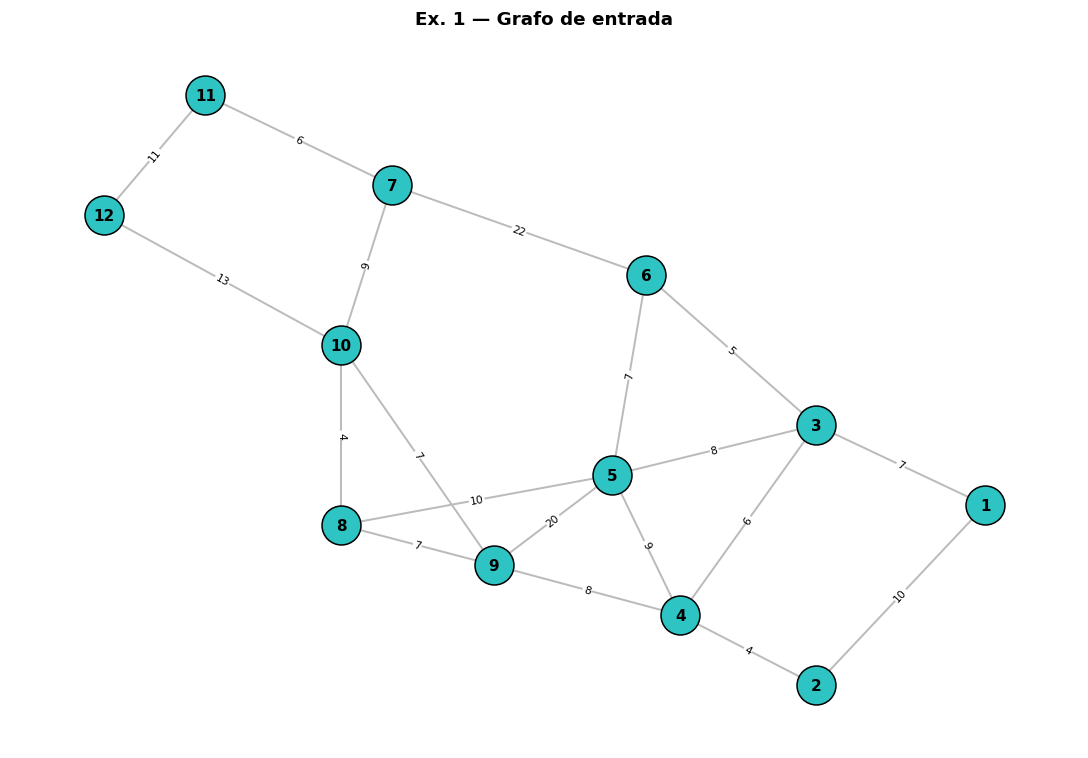

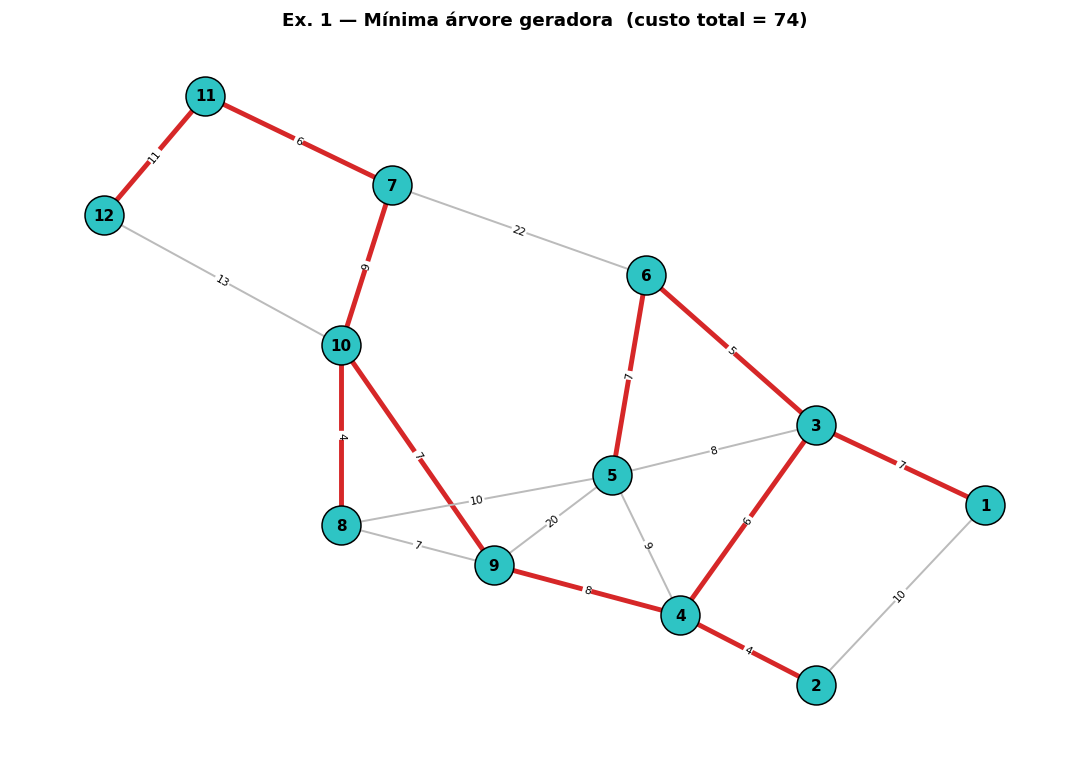

In [63]:
draw_graph(n1, EX1_EDGES, EX1_POS, 'Ex. 1 — Grafo de entrada')
draw_graph(n1, EX1_EDGES, EX1_POS,
           f'Ex. 1 — Mínima árvore geradora  (custo total = {z_k1})',
           tree=tree_k1)

### Exercício 2: Mínima Árvore Geradora (15 nós)

Grafo não-dirigido com 15 nós e 27 arestas. Custo total esperado $= 89$.

In [64]:
EX2_EDGES = [
    (11,15,5),(11,12,11),(11,7,3),(12,7,6),(12,10,13),
    (15,14,7),(7,10,19),(7,14,3),(7,6,22),(14,6,7),(14,13,4),
    (10,8,14),(10,9,17),(10,5,10),(8,9,13),(9,5,11),
    (6,5,7),(6,3,9),(6,13,5),(5,3,8),(5,4,9),
    (3,13,5),(3,1,7),(3,4,6),(13,1,8),(4,2,4),(1,2,10),
]
EX2_POS = {
    11:(4.3,7.0),15:(5.6,6.9),12:(3.3,6.6), 7:(4.4,5.6),
    14:(6.2,5.4),10:(2.6,4.8), 6:(5.2,4.4), 8:(1.0,4.3),
    13:(7.2,4.4), 5:(3.6,3.9), 3:(5.0,3.6), 9:(2.0,3.5),
     4:(4.6,2.6), 1:(6.6,3.0), 2:(4.0,1.8),
}

n2 = list(range(1, 16))
tree_k2, z_k2, log_k2 = kruskal(n2, EX2_EDGES)
tree_p2, z_p2, log_p2 = prim(n2, EX2_EDGES, start=1)

print(f'Kruskal: custo = {z_k2}  |  Prim: custo = {z_p2}')
mst_log_df(log_k2, log_p2)

Kruskal: custo = 89  |  Prim: custo = 89
--- Kruskal ---


,Iter.,Aresta,Peso,Decisão,Obs.
0,1,"(11,7)",3,ACEITA,une {11} e {7}
1,2,"(7,14)",3,ACEITA,une {7} e {14}
2,3,"(14,13)",4,ACEITA,une {14} e {13}
3,4,"(4,2)",4,ACEITA,une {4} e {2}
4,5,"(11,15)",5,ACEITA,une {11} e {15}
5,6,"(6,13)",5,ACEITA,une {6} e {13}
6,7,"(3,13)",5,ACEITA,une {3} e {13}
7,8,"(12,7)",6,ACEITA,une {12} e {7}
8,9,"(3,4)",6,ACEITA,une {3} e {4}
9,10,"(15,14)",7,rejeita,formaria ciclo


--- Prim ---


,Iter.,Aresta,Peso,Decisão,Obs.
0,1,"(1,3)",7,ACEITA,"adiciona nó 3 via (1,3)"
1,2,"(3,13)",5,ACEITA,"adiciona nó 13 via (3,13)"
2,3,"(13,14)",4,ACEITA,"adiciona nó 14 via (13,14)"
3,4,"(14,7)",3,ACEITA,"adiciona nó 7 via (14,7)"
4,5,"(7,11)",3,ACEITA,"adiciona nó 11 via (7,11)"
5,6,"(11,15)",5,ACEITA,"adiciona nó 15 via (11,15)"
6,7,"(13,6)",5,ACEITA,"adiciona nó 6 via (13,6)"
7,8,"(3,4)",6,ACEITA,"adiciona nó 4 via (3,4)"
8,9,"(4,2)",4,ACEITA,"adiciona nó 2 via (4,2)"
9,10,"(7,12)",6,ACEITA,"adiciona nó 12 via (7,12)"


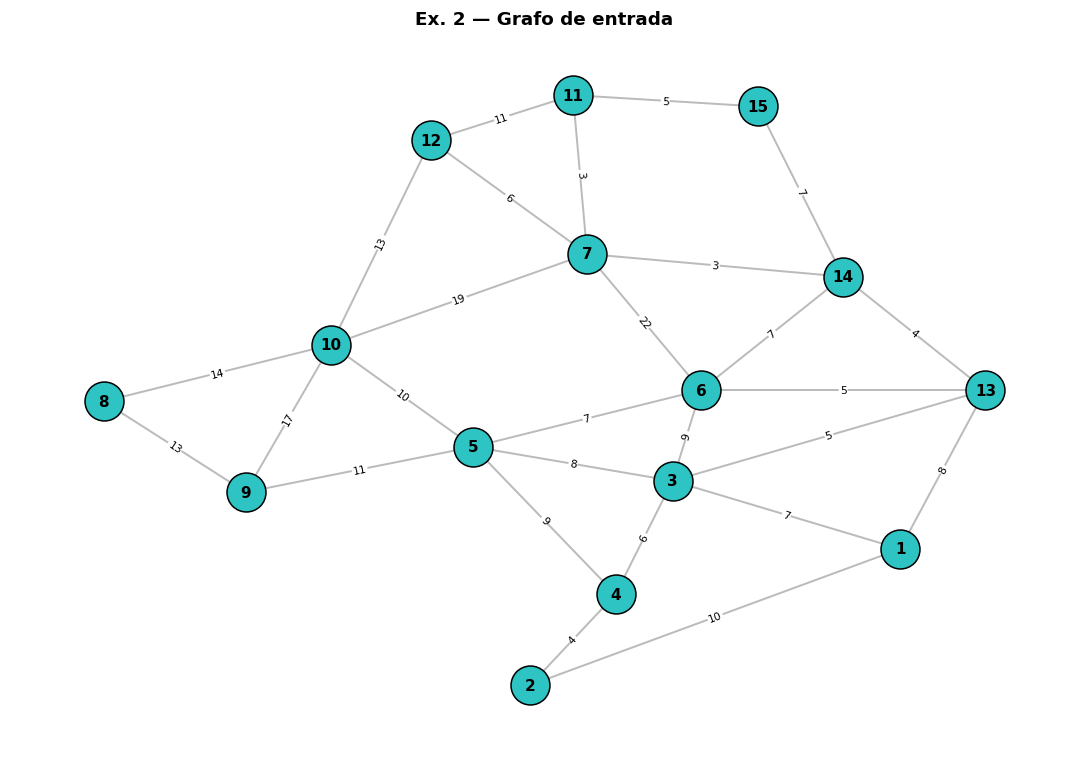

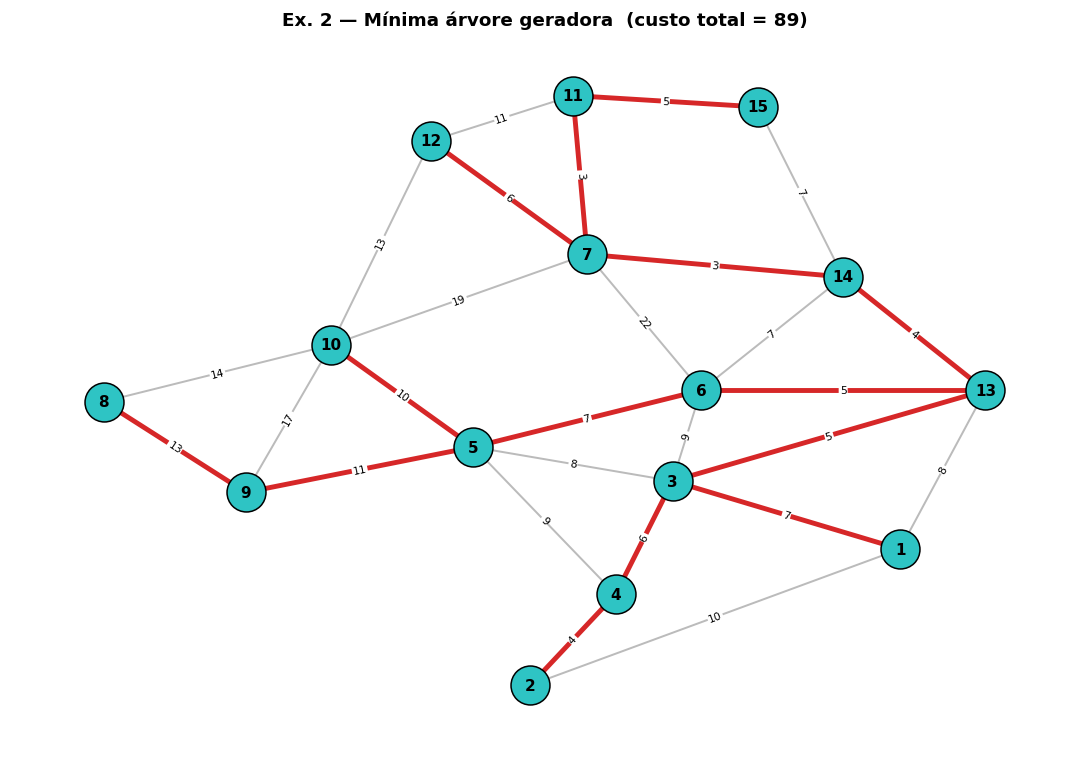

In [65]:
draw_graph(n2, EX2_EDGES, EX2_POS, 'Ex. 2 — Grafo de entrada')
draw_graph(n2, EX2_EDGES, EX2_POS,
           f'Ex. 2 — Mínima árvore geradora  (custo total = {z_k2})',
           tree=tree_k2)

### Exercício 5: Fluxo Máximo (Edmonds-Karp)

Grafo **dirigido** com 15 nós; fonte $s = 1$, sumidouro $t = 15$.

**Modelo matemático:**
$$\max\; F = \sum_{j:(1,j)\in A} f_{1j}$$

- Conservação: $\displaystyle\sum_{j:(i,j)\in A} f_{ij} - \sum_{j:(j,i)\in A} f_{ji} = 0 \quad \forall\, i \neq 1, 15$
- Capacidade: $0 \leq f_{ij} \leq u_{ij} \quad \forall\,(i,j) \in A$

O algoritmo de **Edmonds-Karp** utiliza BFS para encontrar o caminho aumentante de menor número de arestas a cada iteração.

In [66]:
EX5_ARCS = [
    (1,2,13),(1,5,46),(1,9,40),(1,10,92),
    (2,3,27),(2,6,80),(2,14,88),
    (3,4,90),(3,7,79),(3,8,26),(3,11,37),(3,12,43),(3,13,42),
    (4,15,44),(5,3,82),(5,6,43),(5,14,46),
    (6,4,80),(6,7,56),(6,8,38),(6,11,74),(6,12,81),(6,13,35),
    (7,15,34),(8,15,63),
    (9,3,47),(9,6,77),(9,14,13),(10,3,19),(10,6,60),(10,14,70),
    (11,15,57),(12,15,74),(13,15,62),
    (14,4,63),(14,7,15),(14,8,59),(14,11,90),(14,12,74),(14,13,45),
]
EX5_POS = {
     7:(5.0,7.2),10:(2.8,6.0),13:(7.2,6.0), 5:(1.8,4.8),
    14:(4.6,4.9), 8:(7.2,4.9), 1:(0.6,3.8), 3:(5.0,3.8),
    15:(8.4,3.8), 9:(1.8,2.7), 6:(4.0,2.8), 4:(6.2,2.2),
     2:(2.4,1.3),11:(5.0,0.8),12:(6.6,1.0),
}

n5 = list(range(1, 16))
mf, pos_fl, steps = edmonds_karp(n5, EX5_ARCS, source=1, sink=15)

print(f'Fluxo máximo: {mf}')
print(f'Soma das capacidades da fonte: 13+46+40+92 = {13+46+40+92} (todos os arcos saturados)')
display(pd.DataFrame(steps))

Fluxo máximo: 191
Soma das capacidades da fonte: 13+46+40+92 = 191 (todos os arcos saturados)


,Caminho,Gargalo,Fluxo acum.
0,1 -> 9 -> 3 -> 4 -> 15,40,40
1,1 -> 2 -> 3 -> 4 -> 15,4,44
2,1 -> 2 -> 3 -> 7 -> 15,9,53
3,1 -> 10 -> 3 -> 7 -> 15,19,72
4,1 -> 10 -> 6 -> 7 -> 15,6,78
5,1 -> 10 -> 6 -> 8 -> 15,38,116
6,1 -> 10 -> 6 -> 11 -> 15,16,132
7,1 -> 10 -> 14 -> 8 -> 15,13,145
8,1 -> 5 -> 3 -> 8 -> 15,12,157
9,1 -> 5 -> 3 -> 11 -> 15,34,191


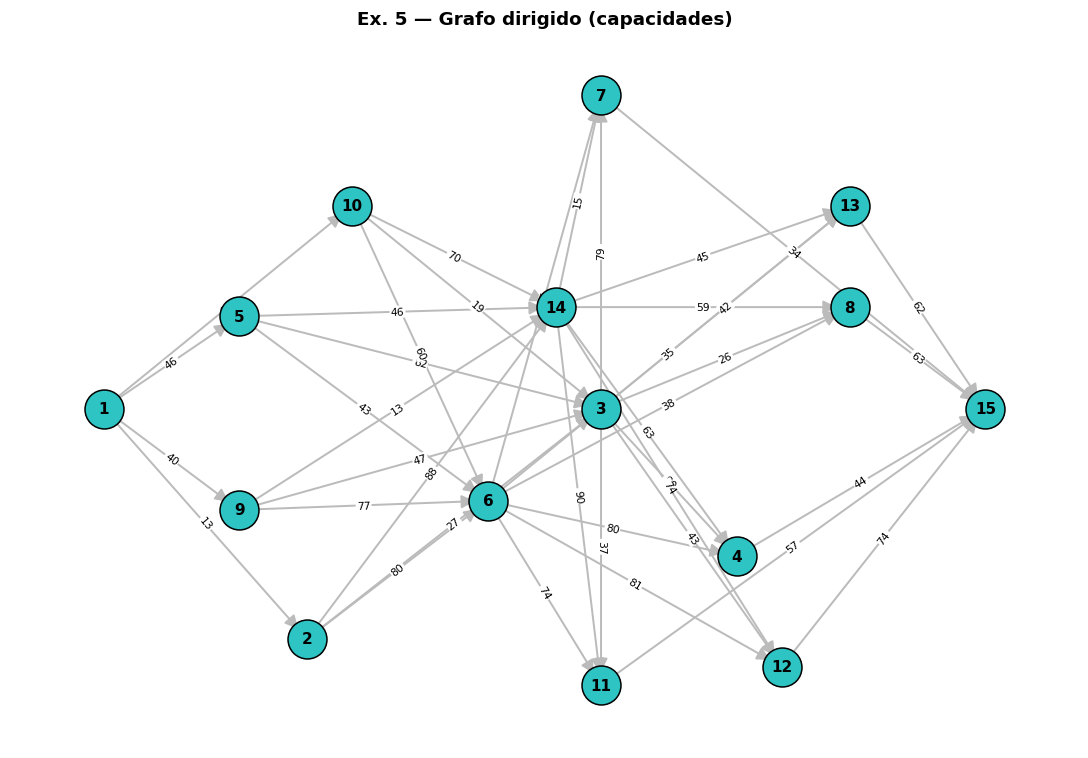

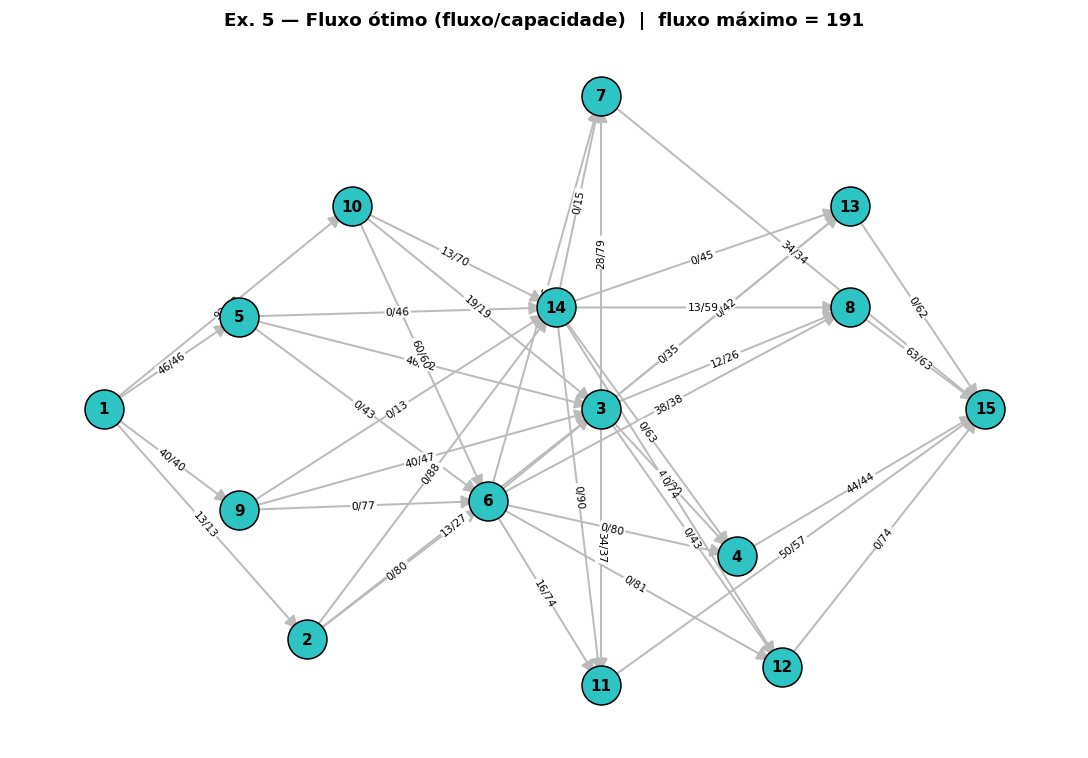

In [67]:
draw_graph(n5, EX5_ARCS, EX5_POS,
           'Ex. 5 — Grafo dirigido (capacidades)',
           directed=True)
draw_graph(n5, EX5_ARCS, EX5_POS,
           f'Ex. 5 — Fluxo ótimo (fluxo/capacidade)  |  fluxo máximo = {mf}',
           directed=True, flow=pos_fl)